# Exploratory Data Analysis (EDA) - Lyon

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Load the ML Dataset

In [2]:
# Load the Lyon noise ML dataset
dataset = pd.read_csv("data/lyo_noise_class_ml_dataset.csv")

print(f"Dataset shape: {dataset.shape}")
dataset.head()
print(dataset.columns.tolist())

Dataset shape: (7159, 22)
['road_id', 'noise_day', 'noise_evening', 'noise_night', 'road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'betweenness', 'closeness_global', 'closeness_400', 'straightness', 'green', 'industrial', 'commercial']


## Reduce the number of columns

In [3]:
print(dataset.columns.tolist())

['road_id', 'noise_day', 'noise_evening', 'noise_night', 'road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'betweenness', 'closeness_global', 'closeness_400', 'straightness', 'green', 'industrial', 'commercial']


<Axes: >

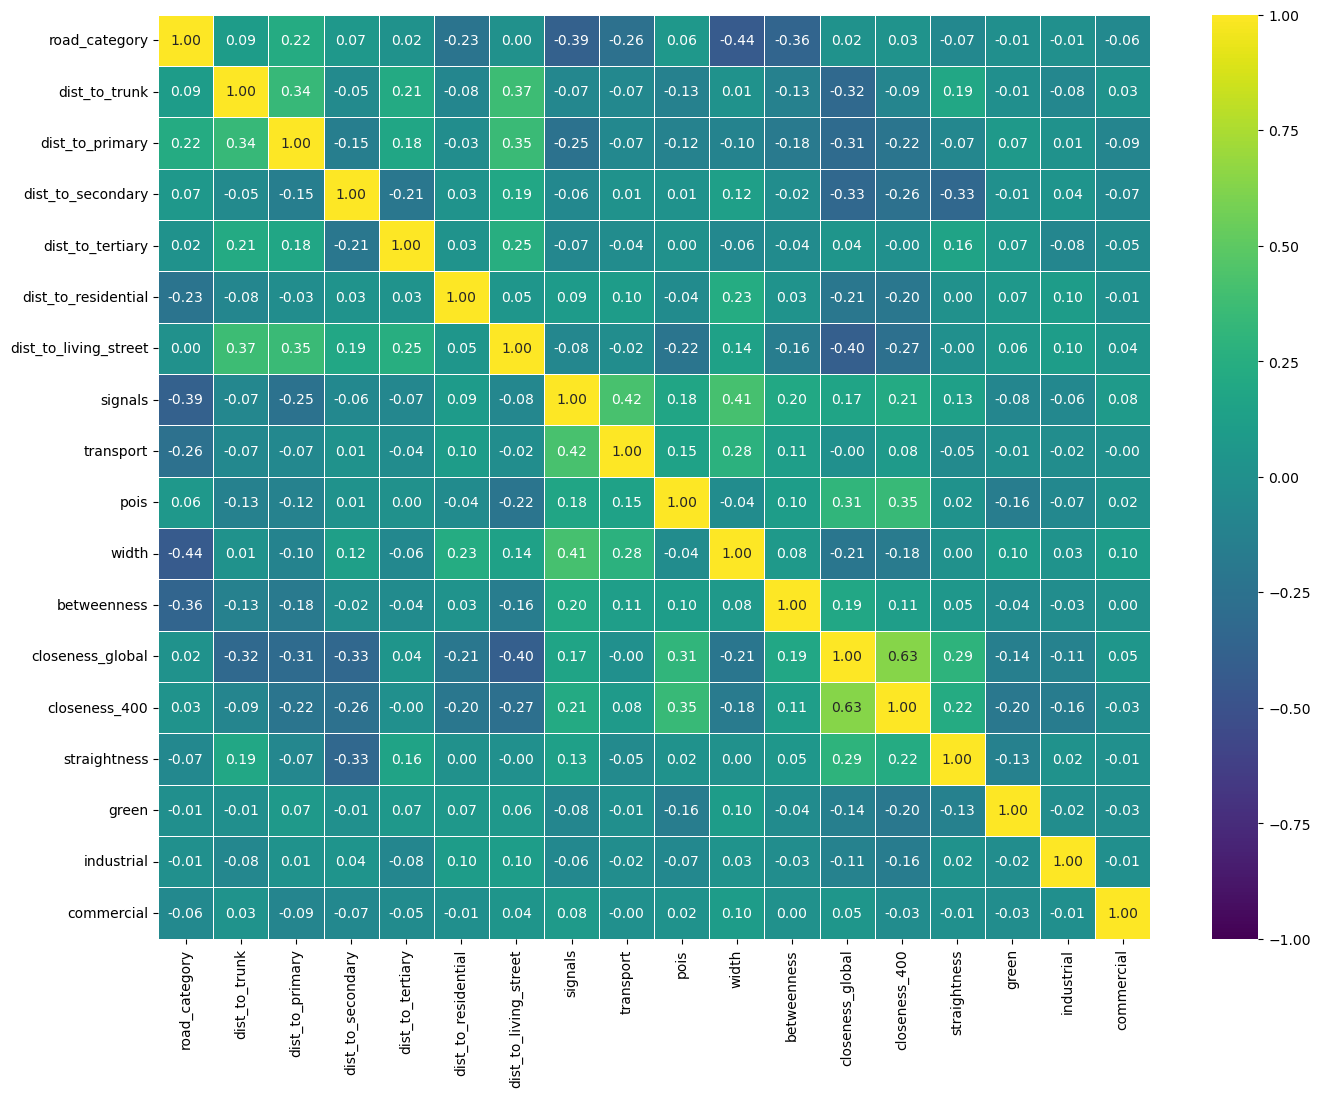

In [4]:
dataset_features = dataset.drop(columns=['road_id', 'noise_day', 'noise_evening', 'noise_night'])
plt.figure(figsize=(16, 12))
sns.heatmap(dataset_features.corr(), center=0, linewidths=0.5,
            cmap="viridis", vmin=-1, vmax=1, annot=True, fmt=".2f")

## Calculate Spearman correlation

Pearson measures linear relationships
-> very sensitive to outliers and nonlinear patterns

Spearman measures rank-order relationships
-> works well with nonlinear relationships and is more robust to outliers

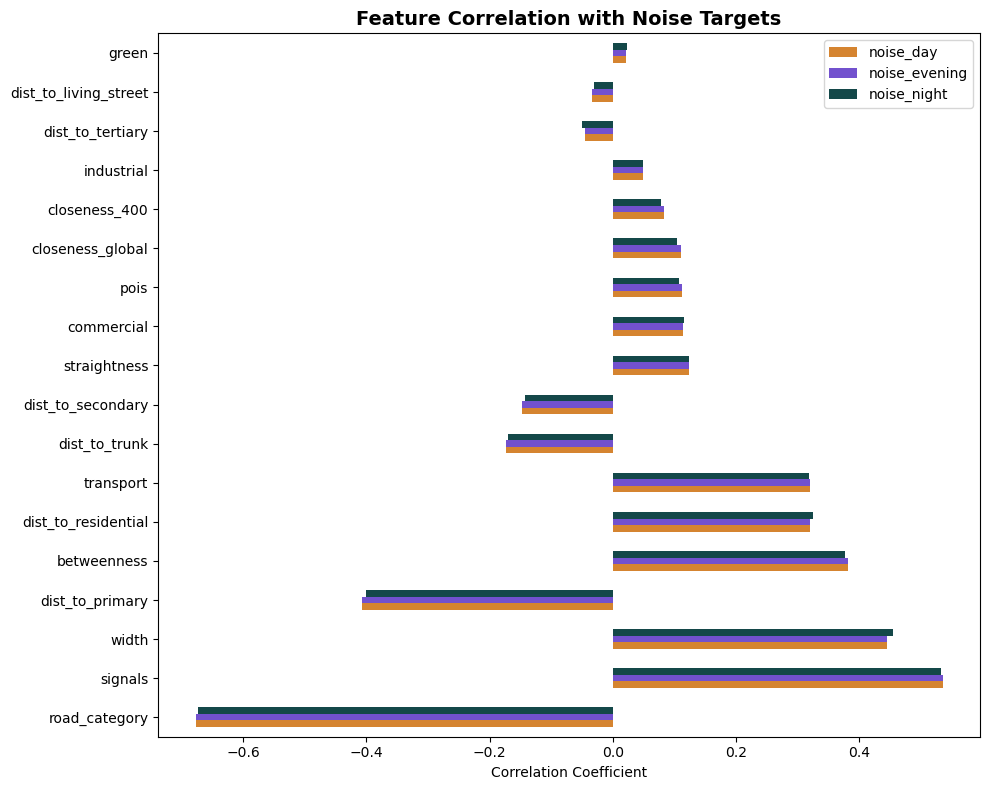

                       noise_day  noise_evening  noise_night
signals                 0.535684       0.535684     0.533290
width                   0.445404       0.445404     0.455494
betweenness             0.382270       0.382270     0.377567
dist_to_residential     0.321029       0.321029     0.325547
transport               0.319517       0.319517     0.318541
straightness            0.124068       0.124068     0.124547
commercial              0.113859       0.113859     0.116143
pois                    0.112623       0.112623     0.106751
closeness_global        0.110634       0.110634     0.103642
closeness_400           0.083702       0.083702     0.078343
industrial              0.049197       0.049197     0.048612
green                   0.021323       0.021323     0.022839
dist_to_living_street  -0.033855      -0.033855    -0.031072
dist_to_tertiary       -0.044647      -0.044647    -0.050341
dist_to_secondary      -0.147319      -0.147319    -0.142929
dist_to_trunk          -

In [5]:
dataset_filtered = dataset.drop(columns=['road_id'])
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method='spearman')[target_cols].drop(target_cols)

feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(
    kind='barh', ax=ax, color=['#d58430', '#7251ce', '#144849'])
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

In [6]:
dataset_pairs = dataset.drop(columns=['road_id', 'noise_evening', 'noise_night'])

sample = dataset_pairs.sample(n=1000, random_state=42).copy()

sorted_noise_values = sorted(sample['noise_day'].unique())
sample['noise_day'] = pd.Categorical(sample['noise_day'], categories=sorted_noise_values, ordered=True)

In [7]:
print("Noise Day values:")
print(dataset['noise_day'].unique())
print("\nUnique values count:", dataset['noise_day'].nunique())

Noise Day values:
[4 3 2 1]

Unique values count: 4
